<a href="https://colab.research.google.com/github/Mohamedelshshtawy-eng/Nodejs/blob/main/IBMProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ================================
# Question 1: Tesla Stock Data
# ================================
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

# Extract Tesla stock data
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")

# Reset index
tesla_data.reset_index(inplace=True)

# Display first 5 rows
print("Tesla Stock Data (first 5 rows):")
print(tesla_data.head())

Tesla Stock Data (first 5 rows):
                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  


In [12]:
# ================================
# Question 2: Tesla Revenue Data
# ================================
url_tesla = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
html_data_tesla = requests.get(url_tesla).text
soup_tesla = BeautifulSoup(html_data_tesla, "html.parser")

tables = soup_tesla.find_all("table")
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in tables:
    rows = table.find_all("tr")
    for row in rows:
        cols = row.find_all("td")
        if len(cols) == 2:
            date = cols[0].text.strip()
            revenue = cols[1].text.strip().replace(",", "").replace("$", "")
            if revenue and revenue != "":  # remove empty rows
                tesla_revenue = pd.concat([tesla_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})], ignore_index=True)

# Clean data
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]
tesla_revenue["Revenue"] = pd.to_numeric(tesla_revenue["Revenue"], errors="coerce")

# Display last 5 rows
print("Tesla Revenue Data (last 5 rows):")
print(tesla_revenue.tail())


Tesla Revenue Data (last 5 rows):
Empty DataFrame
Columns: [Date, Revenue]
Index: []


In [13]:
# ================================
# Question 3: GameStop Stock Data
# ================================
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")

# Reset index
gme_data.reset_index(inplace=True)

# Display first 5 rows
print("GameStop Stock Data (first 5 rows):")
print(gme_data.head())


GameStop Stock Data (first 5 rows):
                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620128  1.693350  1.603296  1.691666  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716073  1.670626  1.683250  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658002  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


In [14]:
# ================================
# Question 4: GameStop Revenue Data
# ================================
url_gme = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
html_data_gme = requests.get(url_gme).text
soup_gme = BeautifulSoup(html_data_gme, "html.parser")

tables = soup_gme.find_all("table")
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in tables:
    rows = table.find_all("tr")
    for row in rows:
        cols = row.find_all("td")
        if len(cols) == 2:
            date = cols[0].text.strip()
            revenue = cols[1].text.strip().replace(",", "").replace("$", "")
            if revenue and revenue != "":
                gme_revenue = pd.concat([gme_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})], ignore_index=True)

# Clean data
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]
gme_revenue["Revenue"] = pd.to_numeric(gme_revenue["Revenue"], errors="coerce")

# Display last 5 rows
print("GameStop Revenue Data (last 5 rows):")
print(gme_revenue.tail())

GameStop Revenue Data (last 5 rows):
Empty DataFrame
Columns: [Date, Revenue]
Index: []


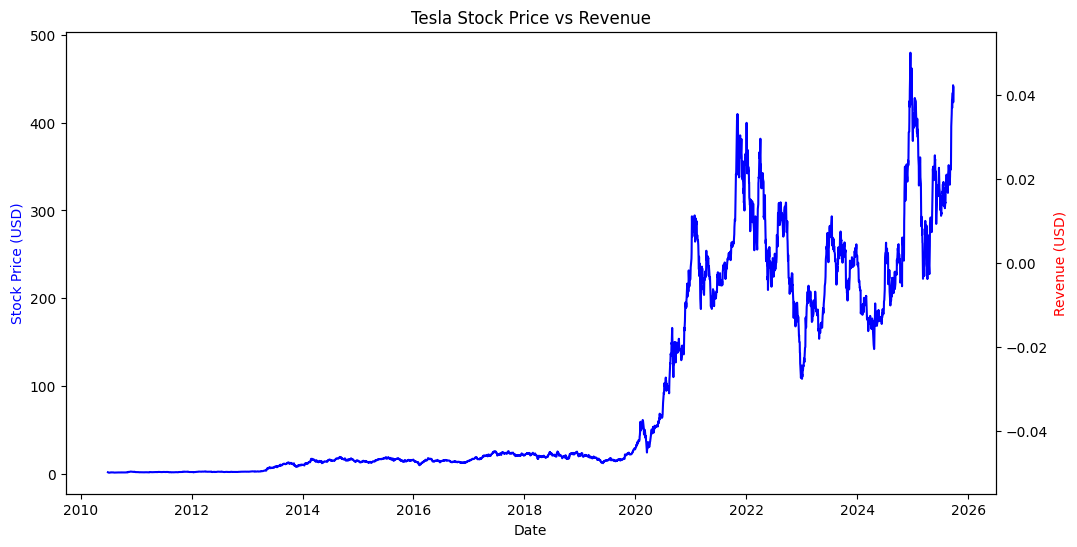

In [15]:
# ================================
# Question 5: Tesla Stock & Revenue Graph
# ================================
def make_graph(stock_data, revenue_data, stock_name):
    fig, ax1 = plt.subplots(figsize=(12,6))

    ax1.plot(stock_data["Date"], stock_data["Close"], color="blue", label="Stock Price")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Stock Price (USD)", color="blue")

    ax2 = ax1.twinx()
    ax2.plot(revenue_data["Date"], revenue_data["Revenue"], color="red", label="Revenue")
    ax2.set_ylabel("Revenue (USD)", color="red")

    plt.title(f"{stock_name} Stock Price vs Revenue")
    plt.show()

make_graph(tesla_data, tesla_revenue, "Tesla")



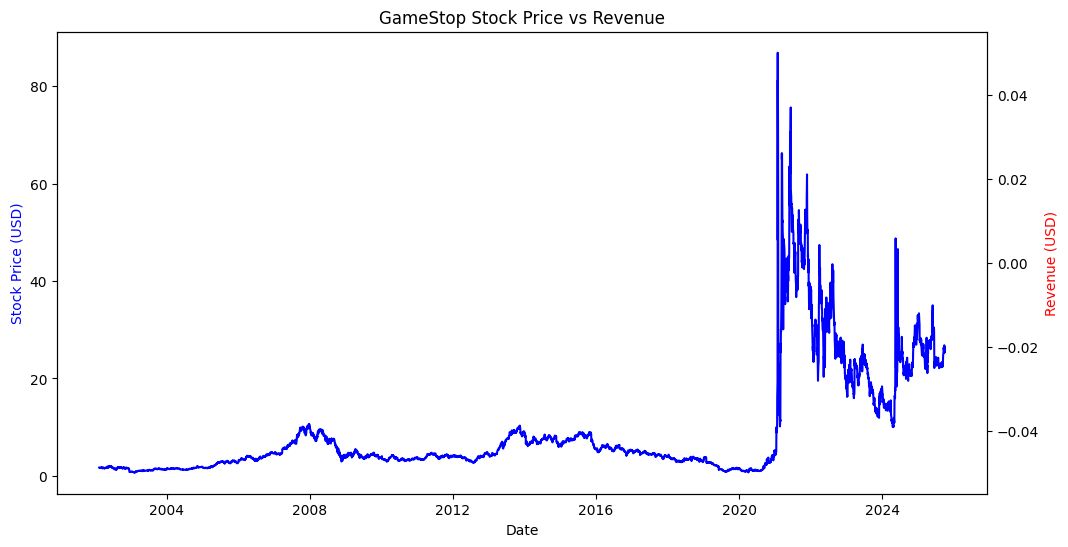

In [16]:
# ================================
# Question 6: GameStop Stock & Revenue Graph
# ================================
make_graph(gme_data, gme_revenue, "GameStop")
